In [13]:
# Surface Wave Plots David Glacier Seismic
# Zachary Katz
# 11 December 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from scipy.signal import find_peaks
import scipy

############
line = '21YY'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 20 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

def segyload_obspy_obj(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    return selected_traces, time, coords


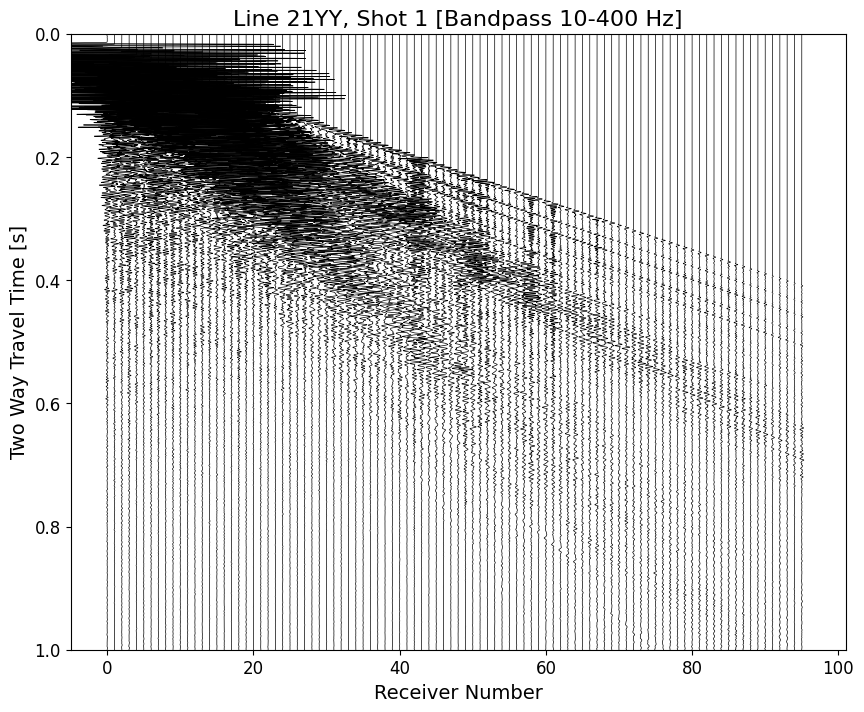

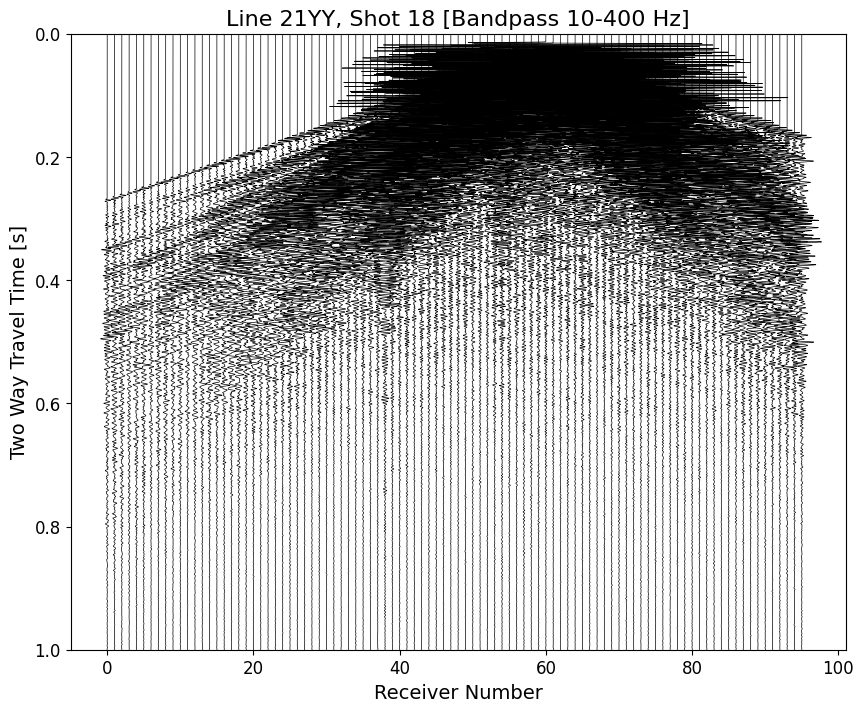

In [40]:
# Full shot filtered wiggle:
for index, fldr_number in enumerate([1,18]):
    fig, ax = plt.subplots(figsize=(10, 8))
    selected_traces, time, coords = segyload_obspy_obj(sgy_path, fldr_number)

    selected_trace_copys = selected_traces.copy()
    freqmax = 400
    freqmin = 10
    for tr in selected_trace_copys:
        tr.filter('bandpass', freqmin=freqmin, freqmax=freqmax)

    for i, tr in enumerate(selected_trace_copys):
        ax.plot(tr.data * 0.2 + i, time, color='black', linewidth=0.5)
    
    ax.set_xlim(-5, len(selected_traces)+5)
    ax.set_ylim(1, 0)

    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number} [Bandpass {freqmin}-{freqmax} Hz]",fontsize=16)
    ax.tick_params(labelsize=12)
    

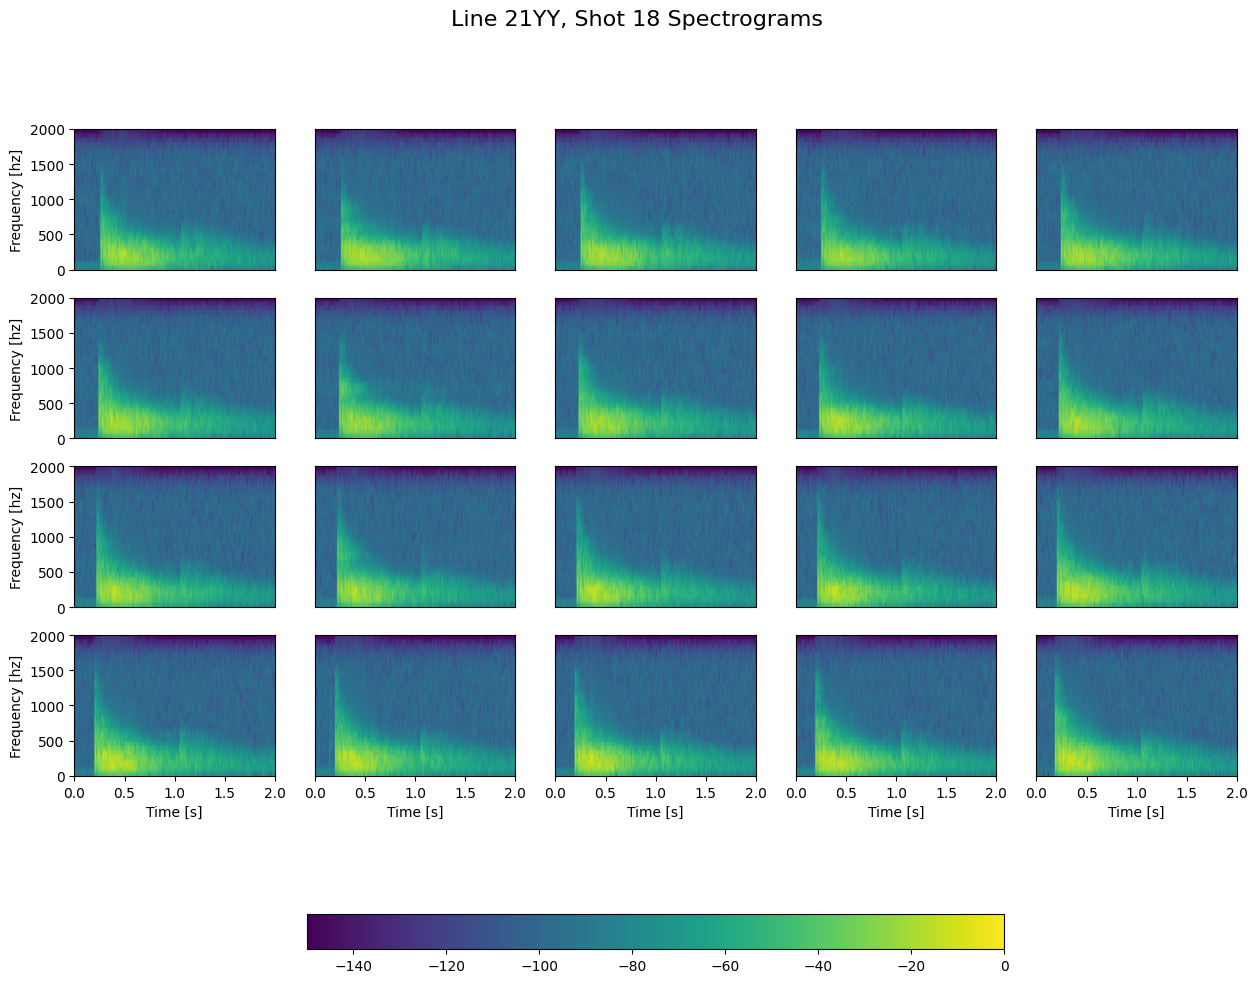

In [63]:
# Full shot spectrogram:
for index, fldr_number in enumerate([18]):
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 20 traces
    selected_traces, time, coords = segyload_obspy_obj(sgy_path, fldr_number)

    selected_trace_copys = selected_traces.copy()
    axes = axes.ravel()

    fs = 1.0 / (time[1] - time[0])

    # Plot spectrogram for the first 20 traces (or fewer if not enough)
    n_plot = min(20, len(selected_traces))

    for i in range(n_plot):
        ax = axes[i]
        tr = selected_trace_copys[i].data

        Pxx, freqs, bins, im = ax.specgram(
            tr,
            NFFT=64,
            Fs=fs,
            noverlap=63,
            cmap='viridis'
        )
        ax.set_xlim(0,2)
        ax.set_ylim(0,2000)

        ax.set_xticks([])
        ax.set_yticks([])
        #print(im.get_clim())
        im.set_clim(-150, 0)


    # X labels on bottom row (row = 3 → indices 15–19)
    for j in range(15, 20):
        if j < n_plot:
            axes[j].set_axis_on()
            axes[j].set_xlabel("Time [s]", fontsize=10)
            axes[j].set_xticks([0, 0.5, 1.0, 1.5, 2.0])

    # Y labels on left column (indices: 0,5,10,15)
    for j in [0, 5, 10, 15]:
        if j < n_plot:
            axes[j].set_axis_on()
            axes[j].set_ylabel("Frequency [hz]", fontsize=10)
            axes[j].set_yticks([0, 500, 1000, 1500, 2000])

    cbar = fig.colorbar(im, ax=axes, shrink=0.6, location='bottom')

    fig.suptitle(f"Line {line}, Shot {fldr_number} Spectrograms", fontsize=16)